In [1]:
forget()
import statistics
import math
import os
import numpy as np
from scipy.stats import linregress
import matplotlib.pyplot as plt
from IPython.core.display import display, HTML
from matplotlib.ticker import MaxNLocator
from matplotlib.patches import Rectangle  # Add this import statement
# COMENÇA EL PROGRAMA, NO CAL FER RES AQUÍ
global gravedad
global incerteses_sw

incerteses_sw =[]
gravedad = 9.8

class Measure:
    objects = []

    def __init__(self,name, variable_name, mag_inc, unitats):
#         assert (magnitude.parent() == RR) and (incertesa.parent() == RR) and (isinstance(units, str)
        self.name = name

        self.var_name = variable_name
        self.var_inc_name = f"{variable_name}_inc"
        self.var = var(variable_name)
        self.var_inc = var(f"{variable_name}_inc")

#         self.magnitude = mag_inc[0].n()
#         self.incertesa = mag_inc[1].n()


        if isinstance(mag_inc[0], np.float):
            self.magnitude = mag_inc[0]
        else:
            self.magnitude = mag_inc[0].n()
#         print("From measure, magitud e incertesa:",mag_inc[0],mag_inc[1] )
        if isinstance(mag_inc[1], np.float):
            self.incertesa = mag_inc[1]
        else:
            self.incertesa = mag_inc[1].n()

        self.unitats = unitats

        Measure.objects.append(self)


    def __repr__(self):
        if type(self.magnitude) == float:
            return repr(f"{(self.name).capitalize()}: ({self.magnitude} +/- {self.incertesa}) {self.unitats}")            
        else:
            return repr(f"{(self.name).capitalize()}: ({self.magnitude} +/- {self.incertesa}) {self.unitats}")

class Measure_list(Measure):
    def __init__(self,variable_name, name, valors,inc_inst, unitats):
        assert isinstance(valors, list), "fica una llista"
        suma = 0
        val_prom = mean(valors)
        num = len(valors) - 1
        for x in valors:
            suma += (val_prom-x)**2

        stdev = sqrt(suma/num)
        inc_est = stdev/sqrt(num + 1)

        inc = sqrt((inc_est**2) + (inc_inst**2))
        Measure.__init__(self, variable_name, name, [val_prom,inc], unitats)

        self.stdev = stdev
        self.inc_ins = inc_inst

    def __repr__(self):
        return f"{(self.name).capitalize()}: ({self.magnitude} +/- {self.incertesa}) {self.unitats}\n\t[Stdev : {self.stdev}, Inc. Instrumental:{self.inc_ins}]"

class Physics_magnitude:
#    gravity = 9.8

    def __init__(self, equation, variables):
        # Initializing values
        self.formula = equation
#         Both following have same order, contain var values
        self.variable_list = [variable.var for variable in variables]
        self.variable_inc_list = [variable.var_inc for variable in variables]

        self.variable_and_inc_list = []
        for variable, variable_inc in zip(self.variable_list, self.variable_inc_list):
            self.variable_and_inc_list.extend([variable,variable_inc])

#         Comprovem que hi ha el mateix NOMBRE de variables a l'equació proporcionada
        try:
            temp = self.formula(1)
            for x in range(1,len(variables)):
                temp = temp(1)
        except:
            ValueError("El nombre de variables de la funció i les proporcionades no coincideix")

        # Defining incertesa
        self.incertesa= self.incertesa_combinada_simbolica()

    def incertesa_combinada_simbolica(self):
        inc_comb = 0
        # CAMBIAR CON LO AHORA HECHO DE INCERTESES
        for variable, variable_inc in zip(self.variable_list, self.variable_inc_list):
            inc_comb += ((self.formula).diff(variable)*variable_inc)**2 
        inc_comb = sqrt(inc_comb)

#         show(self.formula)
        incerteses_sw.append(inc_comb)

        for variable in self.variable_list:
            inc_comb += variable
        return inc_comb

    def evaluate(self, valores):
        #evalua en el orden pasado a la clase llamada
        # Preparando carnita: (valores tiene que ser un objecto Measure)
        account = []
        for valor in valores:
            account.extend([(valor.var_name, valor.magnitude), (valor.var_inc_name, valor.incertesa)])

        # Eliminamos posibles repeticiones de valores para que, en evaluar, no se repita la misma evaluación
#         print("Before", account)
        account = set(account)
        account = list(account)
#         print("After",account)

        account.sort() # Tiene que estar según el orden alfabético
#         show("Account", account)
#         show("Formula", self.formula,"Incertesa", self.incertesa)
        temp1 = self.formula
        temp2 = self.incertesa
#         show("This is temp1", temp1)
#         show("This is temp2", temp2)
#         print("This is account \n",account)
        for x in account:
#             show(temp2)
            
#             show("Temp2", temp2, temp2.arguments())
#             print("Temp1", temp1, temp1.arguments())
            if  not ((str(x[0]))[-4:] == "_inc"):
                temp2 = (temp2) - (x[1])
            
            if temp2.arguments() != ():
#                 show(temp2, "evaluated at", x)

                temp2 = (temp2)(x[1])
#                 print("Hola")

    #             show("Result:",temp2)

            
            if  not ((str(x[0]))[-4:] == "_inc") and temp1.arguments() != ():
#                 show(temp1, "evaluated at", x)
                temp1 = (temp1)(x[1])
#                 show("temp1 result", temp1)
#         print([temp1,temp2])
        return [temp1,temp2]

    def __repr__(self):
        return repr(f"Formula: {self.formula}")

def formulador(formula,dades,name,symbol,units): #Importante, las vars han de coincidir
    if isinstance(dades, Measure): dades = [dades]
    magnitud = Physics_magnitude(formula, dades)
    return Measure(name, symbol, magnitud.evaluate(dades),units)


# -----------------------------------------------------------------
# OLD REGRESSION DISPLAYER
# -----------------------------------------------------------------
def linear_regression(x,y,title):
    # Perform linear regression
    B, A, r, p_value, std_err = linregress(x, y)
    A = float(A)
    B = float(B)
    r = float(r)
    # Calculate uncertainties
    B_inc, A_inc = uncertainties(x, y, B, A)
    B_inc = float(B_inc)
    A_inc = float(A_inc)
    # Plot the linear regression
    plt.scatter(x, y)
    plt.plot(x, A + B*np.array(x), color='red')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.savefig('foo.png')
    plt.ylim([0, 4500])
    plt.show()
    return Measure(f"A_{title}",f"A_{title}", [A, A_inc], " "), Measure(f"B_{title}",f"B_{title}", [B, B_inc], " "), Measure(f"r_{title}",f"r_{title}", [r, 0], " ")

def incerteses_regresio(x, y, slope, intercept):
    x = np.array(x)
    y = np.array(y)
    n = len(x)
    sum_x = np.sum(x)
    sum_y = np.sum(y)
    sum_xy = np.sum(x*y)
    sum_x_squared = np.sum(x**2)
    delta = n*sum_x_squared - sum_x**2
    sigma2 = 0
    for xa,ya in zip(x,y):
        sigma2+= (ya- intercept - slope*xa)**2
    sigma2 = sigma2/(n-2)
    uncertainty_slope = sqrt(sigma2*n/delta)
    uncertainty_intercept = sqrt(sigma2* sum_x_squared/delta)
    return uncertainty_slope, uncertainty_intercept


# -----------------------------------------------------------------
# GRAPH DISPLAYER
# -----------------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np
from typing import List, Union, Tuple

def graph_display(datasets: List[List[Tuple[Union[float, Measure], Union[float, Measure]]]],
                  x_label: str, x_units: str, y_label: str, y_units: str, title: str,
                  filename: str, labels: List[str] = None, colors: List[str] = None, components: List[int] = None, 
                  ymin=None, ymax=None, xmin=None, xmax=None, fouraxis=False, grid=False, add_data_points=False,
                  is_first_teo=False, llista_teos=None, legend_outside=False,markersize=4):
    import matplotlib.ticker as mticker

    fig, ax = plt.subplots(figsize=(10, 6))
    myfont = 18

    if colors is None:
        colors = ["black" for _ in datasets]
    while len(colors) < len(datasets):
        colors.append("black")

    if components is None:
        components = [1 for _ in datasets]
    while len(components) < len(datasets):
        components.append(1)

    # Plot datasets
    for i, data in enumerate(datasets):
        mycolor = colors[i]
        xy_data = [
            (
                x.magnitude if isinstance(x, Measure)
                else (x.measure_vector[components[i]].magnitude if isinstance(x, Vector_Measure) else x),
                y.magnitude if isinstance(y, Measure)
                else (y.measure_vector[components[i]].magnitude if isinstance(y, Vector_Measure) else y),
            )
            for x, y in data
        ]
        x_values, y_values = zip(*xy_data)

        x_uncertainty = [
            x.incertesa if isinstance(x, Measure)
            else (x.measure_vector[components[i]].incertesa if isinstance(x, Vector_Measure) else 0)
            for x, _ in data
        ]
        y_uncertainty = [
            y.incertesa if isinstance(y, Measure)
            else (y.measure_vector[components[i]].incertesa if isinstance(y, Vector_Measure) else 0)
            for _, y in data
        ]

        if (len(x_uncertainty) == 0) or (max(x_uncertainty) == min(x_uncertainty) == 0):
            x_uncertainty = None
        if (len(y_uncertainty) == 0) or (max(y_uncertainty) == min(y_uncertainty) == 0):
            y_uncertainty = None

        if llista_teos is None:
            if i == 0:
                fmt_name = "" if is_first_teo else "o"
            else:
                fmt_name = "o" if add_data_points else ""
        else:
            if i < len(llista_teos):
                fmt_name = llista_teos[i]
            else:
                fmt_name = ""

        label = labels[i] if (labels is not None and i < len(labels)) else f"label{i + 1}"

        ax.errorbar(
            x_values, y_values,
            xerr=x_uncertainty, yerr=y_uncertainty,
            fmt=fmt_name, color=mycolor,
            elinewidth=1, ecolor=mycolor, capsize=2.5, markersize=4,
            label=label
        )

    # Grid
    if grid:
        ax.grid(linestyle="dotted")
    else:
        ax.yaxis.grid(False)

    # Labels & title
    ax.set_ylabel(f'{y_label}' if (y_units == " " or y_units == "") else f'{y_label} ({y_units})', fontsize=myfont)
    ax.set_xlabel(f'{x_label}' if (x_units == " " or x_units == "") else f'{x_label} ({x_units})', fontsize=myfont)
    ax.set_title(title, fontsize=myfont)

    # Optional manual limits
    if xmin is not None or xmax is not None:
        xl, xr = ax.get_xlim()
        if xmin is None: xmin = xl
        if xmax is None: xmax = xr
        ax.set_xlim(left=xmin, right=xmax)
    if ymin is not None or ymax is not None:
        yb, yt = ax.get_ylim()
        if ymin is None: ymin = yb
        if ymax is None: ymax = yt
        ax.set_ylim(bottom=ymin, top=ymax)

    if len(datasets) != 1:
        if legend_outside:
            ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), prop={'size': myfont})
            plt.subplots_adjust(right=0.78)  # leave space for the legend
        else:
            ax.legend(loc='best', prop={'size': myfont})

    # Twin axes that MIRROR exactly
    if fouraxis:
        # Freeze left axis state
        left_ylim  = ax.get_ylim()
        left_yticks = ax.get_yticks()
        left_xlim  = ax.get_xlim()
        left_xticks = ax.get_xticks()

        # Top x-axis
        ax2 = ax.twiny()
        ax2.set_xlim(left_xlim)
        ax2.xaxis.set_major_locator(mticker.FixedLocator(left_xticks))
        ax2.set_xticklabels([])

        # Right y-axis (mirror EXACTLY)
        ax3 = ax.twinx()
        ax3.set_ylim(left_ylim)
        ax3.yaxis.set_major_locator(mticker.FixedLocator(left_yticks))  # <- exact same ticks
        ax3.set_yticklabels([])
        ax3.minorticks_off()

    # Aesthetics
    ax.tick_params(axis='both', which='major', labelsize=18)
    ax.tick_params(axis='both', which='minor', labelsize=18)
    plt.tight_layout()
    plt.savefig(filename + '.png', dpi=300, bbox_inches='tight')
    return fig, ax



# -----------------------------------------------------------------
# REGRESSION DISPLAYER
# -----------------------------------------------------------------
def weighted_linear_regression(x, y, weights):
    x = np.array(x)
    y = np.array(y)
    
    # Calcula los productos cruzados ponderados
    weighted_x = x * weights
    weighted_y = y * weights

    # Calcula las sumas ponderadas
    sum_weighted_x = np.sum(weighted_x)
    sum_weighted_y = np.sum(weighted_y)
    sum_weights = np.sum(weights)

    # Calcula los promedios ponderados
    mean_weighted_x = sum_weighted_x / sum_weights
    mean_weighted_y = sum_weighted_y / sum_weights

    # Calcula los coeficientes de la regresión lineal ponderada
    numerator = np.sum((weighted_x - mean_weighted_x) * (weighted_y - mean_weighted_y))
    denominator = np.sum((weighted_x - mean_weighted_x) ** 2)
    slope = numerator / denominator
    intercept = mean_weighted_y - slope * mean_weighted_x

    return slope, intercept

def regresio_proporcional(x,y):
    alpha = sum([xi*yi for xi,yi in zip(x,y)])/sum([xi**2 for xi in x])
    return alpha
    
def regresio(data, x_label, x_units, y_label, y_units, title, file_name, y_var_name = r"y", x_var_name= r"x", fouraxis = False,
             grid =False, ymin=None,ymax=None, xmin=None,xmax=None,percentdreta=0.05,percentesquerra=0.05,mycolor="red",
             proportional = False, weights = None, per_pesos = False):
    # Extract relevant data from input
    i = 0
    isMeasure = False
    for x, _ in data:
        if isinstance(x, Measure) and i==0:
            isMeasure = True
            i +=1

        if i != 0:
            if isinstance(x, Measure) != isMeasure:
                raise Exception("The list you provided to 'graph_display' has to be a list of Measures or a list of Numbers, not mixed.")
    if isMeasure:
        x_values = [x.magnitude for x, _ in data]
        x_uncertainty = [x.incertesa for x,_ in data]
    else:
        x_values = [x for x, _ in data]

    magnitudes = [measure.magnitude for _, measure in data]
    uncertainties = [measure.incertesa for _, measure in data]
    
    if proportional:
        # Perform linear proportional regression
        slope, intercept = regresio_proporcional(x_values, magnitudes), 0
        
    elif per_pesos:
        assert weights != None, "Pleas introduce some weights."
        assert len(weights) == len(magnitudes), "Length of weights should be the same as of the points of regression."
        # Perform linear weighed regression
        slope, intercept = weighted_linear_regression(x_values, magnitudes, weights)
        
    else:
        # Perform linear regression
        slope, intercept = np.polyfit(x_values, magnitudes, 1)
#     print("This is: ",slope,intercept)
    # Incerteses slope i intercept
    u_slope, u_intercept = incerteses_regresio(x_values, magnitudes, slope, intercept)
#     print("Incertesa pendent: ", u_slope, "\nIncertesa al punt y = 0:",u_intercept, "\nValor pendent complet:", slope,"\nValor intersecció y= 0 complet:", intercept)
#     print("RECORDATORI: Posar unitats a tot arreu")
#     print("AVIS: Per altra banda i com a recomanació (no baixa nota) les variables experimentals i funcions s'han d'escriure en cursiva, mentre que les unitats, subíndexs, etc. s'han d'escriure com a caràcter romà recte.")
    # Extend the regression line by creating a broader range of x values
    x_values_extended = np.linspace(min(x_values) * (1 + percentesquerra), max(x_values) * (1 + percentdreta), 100)

    regression_line = [slope * x + intercept for x in x_values_extended]

    # Compute the regression coefficient (R^2)
    correlation_matrix = np.corrcoef(x_values, magnitudes)
    r_squared = correlation_matrix[0, 1] ** 2
    
    fig,ax = graph_display([data], x_label,x_units,y_label,y_units,title,file_name, fouraxis= fouraxis,grid=grid,ymin=ymin,ymax=ymax,xmax=xmax,xmin=xmin,labels=["Punts experimentals"])
        
    # Plot the regression line
    ax.plot(x_values_extended, regression_line, color=mycolor, 
            label=f'Regression line')
    
    ax.legend(loc='best', prop={'size': 18})
    
    return Measure("A","A_var", [intercept, u_intercept], y_units), Measure("B","B_var", [slope, u_slope], " units "), Measure("Coe","r", [r_squared, 0.1], " "), fig, ax

# Example usage:
# graph_display([data1, data2, data3], x_label, x_units, y_label, y_units, title, filename, labels=["label1", "label2", "label3"])

def grafic_barres(data, x_label, x_units, y_label, y_units, title, filename, colorr = "purple"):

    # Extract relevant data from input
    i = 0
    isMeasure = False
    for x, _ in data:
        print("Check", isinstance(x, Measure))
        if isinstance(x, Measure) and i==0:
            isMeasure = True
            i +=1

        if i != 0:
            if isinstance(x, Measure) != isMeasure:
                raise Exception("The list you provided to 'graph_display' has to be a list of Measures or a list of Numbers, not mixed.")
    if isMeasure:
        x_values = [x.magnitude for x, _ in data]
        x_uncertainty = [x.incertesa for x,_ in data]
    else:
        x_values = [x for x, _ in data]

    
    magnitudes = [measure.magnitude for _, measure in data]
    uncertainties = [measure.incertesa for _, measure in data]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    plt.bar(x_values, magnitudes, color=colorr, width=0.2, yerr = uncertainties,capsize=3)
    
    # Adding labels and title
    if y_units == "":
        ax.set_ylabel(f'{y_label}')
    else:
        ax.set_ylabel(f'{y_label} ({y_units})')
        
    if x_units == "":
        ax.set_xlabel(f'{x_label}')
    else:
        ax.set_xlabel(f'{x_label} ({x_units})')
    ax.set_title(title)
    ax.yaxis.grid(False)  
    plt.xticks(harmonics)
    
    # Save the plot to a file and show it
    plt.tight_layout()
    plt.savefig(filename + '.png', dpi=300, bbox_inches='tight')  
    plt.show()
    
# -----------------------------------------------------------------
# TABLE DISPLAYER
# -----------------------------------------------------------------
from typing import List
from decimal import Decimal, ROUND_HALF_UP

def format_number(number):
    if hasattr(number, 'n'):
        numerical_value = number.n()
        str_num = f"{numerical_value}"
        return str_num.rstrip('0').rstrip('.') if '.' in str_num else str_num
    elif isinstance(number, (float, int)):
        str_num = f"{number}"
        return str_num.rstrip('0').rstrip('.') if '.' in str_num else str_num
    else:
        return str(number)

def round_ife(value, decimal_places=0):
    decimal_value = Decimal(str(value))
    rounded_value = decimal_value.quantize(Decimal('1e-{0}'.format(decimal_places)), rounding=ROUND_HALF_UP)
    return float(rounded_value)

def formalise_value(measure):
    magnitude = measure.magnitude
    uncertainty = measure.incertesa
    non_decimal_inc = int(log(abs(uncertainty), 10).n() + 1)
    non_decimal_mag = int(log(abs(magnitude), 10).n() + 1)

    min_non_decimal = min(non_decimal_inc, non_decimal_mag)
    magnitude = magnitude / (10 ** (min_non_decimal))
    uncertainty = uncertainty / (10 ** (min_non_decimal))

    uncertainty_str = str(uncertainty)
    i = 0
    found = False
    for digit in uncertainty_str:
        if digit.isdigit():
            if found == False:
                if digit.isdigit() and digit != '0':
                    found = True
                    continue
                i += 1
            else:
                i += 1
                break

    if not found:
        return [magnitude * 10 ** (min_non_decimal), uncertainty * 10 ** (min_non_decimal)]

    digit_difference = abs(non_decimal_inc - non_decimal_mag)

    inc = str(round_ife(uncertainty, i)).replace(".", ",")
    mag = str(round_ife(magnitude, i)).replace(".", ",")

    if (i > len(str(mag).split(",")[1])):
        mag = mag + "0" * (i - len(mag.split(",")[1]))

    if non_decimal_inc != 0:
        if min_non_decimal != 1:
            return [f"({mag} \pm {inc}) \cdot 10^" +"{"+f"{min_non_decimal}"+"}", measure.unitats]
        else:
            return [f"({mag} \pm {inc}) \cdot 10", measure.unitats]
        
    else:
        return [f"({mag} \pm {inc}) ", measure.unitats]

from IPython.display import HTML, display

def crear_taula(measures, title='', vector=False, component=0, attr='name', formal=False, headers=None):
    if not vector:
        sorted_measures = sorted(measures, key=lambda x: getattr(x, attr))
    else:
        new_measures = []
        for measure in measures:
            new_measures.append(measure.measure_vector[component])
        sorted_measures = sorted(new_measures, key=lambda x: getattr(x, attr))

    html_content = f"<h2 style='text-align: center; font-size: 16px;'>{title}</h2>" if title else ""
    html_content += "<table style='border: 1px solid black; width: adjust; text-align: center;'>"
    html_content += "<tr '>"
    
    if headers:
        html_content += "<tr>"
        for header in headers:
            html_content += f"<th style='text-align: center;'>{header}</th>"
        html_content += "</tr>"
    else:
        if formal:
            html_content += "<tr><th style='text-align: center;'>Name</th><th style='text-align: center;'>Formal Magnitude</th><th style='text-align: center;'>Units</th></tr>"
        else:
            html_content += "<tr><th style='text-align: center;'>Name</th><th style='text-align: center;'>Magnitude</th><th style='text-align: center;'>Incertesa</th><th style='text-align: center;'>Units</th><th style='text-align: center;'>Incertesa Instrumental (if available)</th></tr>"

    for measure in sorted_measures:
        if formal:
            value = formalise_value(measure)
            magnitude_str = value[0]
            unitats_str = value[1]
            incertesa_str = ""
        else:
            magnitude_str = format_number(measure.magnitude)
            incertesa_str = format_number(measure.incertesa)
            unitats_str = measure.unitats

        if isinstance(measure, Measure_list):
            inc_inst_str = format_number(measure.inc_ins)
        else:
            inc_inst_str = "N/A"
            
        if formal:
            html_content += f"<tr><td>{measure.name}</td><td>{magnitude_str+unitats_str}</td></tr>"
        else:
            html_content += f"<tr><td>{measure.name}</td><td>{magnitude_str}</td><td>{incertesa_str}</td><td>{measure.unitats}</td><td>{inc_inst_str}</td></tr>"
            
    html_content += "</table>"
    display(HTML(html_content))

# -----------------------------------------------------------------

def create_latex_table(columns , titol_list, unitats,components = [0]):
    # LaTeX table header
    assert len(columns) == len(titol_list) == len(unitats), "Each measure unit needs a title and units."
    
    n = len(columns)
    
    # Initialising table for the latex table
    croquis_latex = "|" + "".join(["c"] * n ) + "|"
    latex_table = "\\begin{tabular}{" + croquis_latex + "}\n"
    latex_table += "\\hline\n"
    
    # Creating table header
    for i in range(0,n):
        units = unitats[i]
        if i != 0: # Do not add & in the beggining
            latex_table += "&"
        if titol_list[i] == "" or titol_list[i] == " " or titol_list[i] == None:
            latex_table += " "
        else:
            latex_table += f"{titol_list[i]} ({units})"
        
    latex_table += f"\\\\\n"
    latex_table += "\\hline\n"
    
    latex_rows = []
    components_used = 0
    
    # Add rows for each measurement
    for j,column in enumerate(columns):
        for i,entry in enumerate(column):
            if isinstance(entry, Measure):
                processed_entry = "$"+formalise_value(entry)[0] + "$"
            elif isinstance(entry, Vector_Measure):
                if components_used < len(components):
                    components_used += 1
                processed_entry =  "$"+formalise_value(entry.measure_vector[components_used - 1])[0] + "$"
            elif isinstance(entry, str):
                processed_entry = entry
            else:
                processed_entry = "$"+ entry + "$"
            
            if j == 0:
                latex_rows.append([processed_entry])
            else:
                latex_rows[i].append(processed_entry)
    
    max_len_row = len(latex_rows[0]) # With this model, 1st row will be the highest in number
    
    # Adding rows to the main strin 'latex_table'
    for row in latex_rows:
        if len(row) < max_len_row:
            row.extend([" " * (max_len_row - len(row))])
        latex_row = "&".join(row)
        latex_table += latex_row + "\\\\"
    latex_table += "\\hline\n"
    latex_table += "\\end{tabular}"

    return latex_table

# -----------------------------------------------------------------

# LA PART PRINCIPAL DEL PROGRAMA S'ACABA AQUi
import uuid
def UUID():
    return "t" + "".join(str(uuid.uuid4()).split("-"))
# -----------------------------------------------------------------
# COMENCEN LES DEFINICIONS DE FUNCIONS
# -----------------------------------------------------------------

def masa(w, xtra="", g = gravedad):
    return formulador(w.var/g, w, f"Masa{xtra}", f"m_{xtra}", "kg")
def peso(m,xtra =""):
    return formulador(m.var*gravedad,m,f"Peso{xtra}",f"P{xtra}","N")
def densidad_lineal(m,l, xtra = ""):
    return formulador(m.var/l.var, [m,l], f"Densidad lineal {xtra}", f"lambda_{xtra}", "kg/m")
def densidad_lineal_from_B(n: int,l, B,g = gravedad, xtra = "INDUCIDA"):
    return formulador((g * n**2)/(4*B.var*l.var**2), [B,l],f"Densidad lineal{xtra}", f"lambda_{xtra}","kg/m")
def lambda_armonic_n(n:int, l,xtra = ""):
    return formulador(2*l.var/n, [l], f"Longitud Ona {str(n) + xtra}", f"lambdar_{str(n)+ xtra}", "m")
def nueva_for(f,L,n,xtra=""):
    return formulador(f.var * 2 * L.var /n, [f,L], f"NOU {str(n) + xtra}", f"nou_{str(n)+ xtra}", "m")
def vprop_armonic(n:int,l,f): # Qüestió 2
    s = lambda_armonic_n(n,l)
    return formulador(s.var*f.var, [s,l], f"Vprop ({str(n)})", f"v_prop_{str(n)}", "m/s")
def vel(lam,frec,xtra=""):
    return formulador(frec.var * lam.var,[lam,frec], f"VELOCITAT esa: {xtra}", f"velo_{ xtra}", "m/s")
def relacio(f1,f2,xtra=""):
    return formulador(f1.var/f2.var, [f1,f2], "Relació"+ f1.name + "entre"+ f2.name,"q_" + f1.var_name + f2.var_name, " ")
def inverse(A,xtra=""):
    return formulador(1/A.var, [A], "Inversa de "+ A.name , A.var_name +"_inv", A.unitats +r"$^-1$")
def diff(A, B, xtra=""):
    return formulador(A.var-B.var, [A,B], f"Delta ({A.name}-{B.name})", f"delta_prop_{xtra}", "m")
def media(A, B,C,xtra=""):
    return formulador((A.var+B.var+C.var)/3, [A,B,C], f"Media ({A.name} i {B.name} i {C.name})", f"prom_{xtra}", "m")

def scale(scalar, mesura, xtra=""):
    return Measure(mesura.name + xtra, mesura.var_name + xtra, [scalar*mesura.magnitude, scalar * mesura.incertesa], mesura.unitats)

def amplada(longitud_ona,y,L,xtra=""):
    return formulador((longitud_ona.var * L.var)/y.var, [longitud_ona, L,y], f"Amplada experimental{xtra}", f"a_exp{xtra}","cm")

def discrepancia(A_exp, A_teo):
    return formulador((100 * abs(A_exp.var - A_teo.var))/A_teo.var, [A_exp, A_teo], "Discrepancia " + A_exp.name + "-" + A_teo.name, "Delta" + A_exp.var_name + A_teo.var_name, "%")
def angle_to_rad(angle):
    this = scale(pi/180, angle)
    this.unitats = "rad"
    return this
def suma(measures):
    # Creamos una fórmula simbólica que representa la suma de las magnitudes
    formula = sum(measure.var for measure in measures)
    nombre = ""
    var_nombre = "Sum"
    i = 1
    for name, variable in zip([measure.name for measure in measures], [measure.var_name for measure in measures]):
        nombre +=  name.capitalize()
        if i != len(measures):
            nombre+=" + "
        i+=1
        var_nombre += "_" + variable
#     print("FORMULA", formula)
    # Utilizamos formulador para crear un nuevo Measure
    return formulador(formula, measures, nombre, var_nombre, measures[0].unitats)

def diff(measures):
    assert len(measures) == 2, "Difference must be between two values"
    measure1 = measures[0]
    measure2 = measures[1]
    # Creamos una fórmula simbólica que representa la diferencia de las magnitudes
    formula = measure1.var - measure2.var
    # Utilizamos formulador para crear un nuevo Measure
    return formulador(formula, [measure1, measure2], "Diferencia", "D" + measure1.var_name + measure2.var_name, measure1.unitats)
def mult(measures):
    formula = 1
    for measure in measures:
        formula = formula * measure.var
    return formulador(formula, measures, "Multiplicación " + measures[0].name, UUID(), measures[0].unitats)
        
def promedio(measures):
    # Creamos una fórmula simbólica que representa el promedio de las magnitudes
    formula = sum(measure.var for measure in measures) / len(measures)
    # Utilizamos formulador para crear un nuevo Measure
    return formulador(formula, measures, measures[0].name[:-1] + "Promig", measures[0].var_name +"_promig", measures[0].unitats)

# ADDITIONAL RESOURCES FOR PLOTTING

def data_prepare_formula(formula, xmin, xmax):
    x_vals = np.linspace(xmin ,xmax, 1000)
    return [(float(x), float(formula(x))) for x in x_vals]

<>:549: DeprecationWarning: invalid escape sequence \p
<>:549: DeprecationWarning: invalid escape sequence \c
<>:551: DeprecationWarning: invalid escape sequence \p
<>:551: DeprecationWarning: invalid escape sequence \c
<>:554: DeprecationWarning: invalid escape sequence \p
<>:549: DeprecationWarning: invalid escape sequence \p
<>:549: DeprecationWarning: invalid escape sequence \c
<>:551: DeprecationWarning: invalid escape sequence \p
<>:551: DeprecationWarning: invalid escape sequence \c
<>:554: DeprecationWarning: invalid escape sequence \p
<>:549: DeprecationWarning: invalid escape sequence \p
<>:549: DeprecationWarning: invalid escape sequence \c
<>:551: DeprecationWarning: invalid escape sequence \p
<>:551: DeprecationWarning: invalid escape sequence \c
<>:554: DeprecationWarning: invalid escape sequence \p
<ipython-input-1-ca68319d0a32>:549: DeprecationWarning: invalid escape sequence \p
  return [f"({mag} \pm {inc}) \cdot 10^" +"{"+f"{min_non_decimal}"+"}", measure.unitats]
<ip

In [2]:
def vector_posició(i, magnituds_incerteses):
    return Vector_Measure(f"Posició {str(i)}", f"r_{str(i)}", [magnituds_incerteses[0], magnituds_incerteses[1]], "m")

def velocitat(i,r1,r2,xtra="m_1"):
    deltatemps = 0.04 # s
    velocitat = (r2 - r1)/ (deltatemps)
    velocitat.name = "Velocitat "+ str(i)+ xtra
    velocitat.var_name = "v_"+ str(i)+ xtra
    velocitat.var = var("v_"+ str(i)+ xtra)
    velocitat.var_inc = var(f"v_{str(i)+ xtra}_inc")
    velocitat.unitats = "m/s"
    return velocitat

def p(M, v, i,xtra="m_1"):
    p = v * M
    p.name = "Moment lineal " + str(i)+ xtra
    p.var_name = "p_" + str(i)+ xtra
    p.var = var("p_" + str(i)+ xtra)
    p.var_inc=var(f"p_{str(i)+ xtra}_inc")
    p.unitats = "kg m/s"
    
    return p

def Ec(M,v,i,xtra="m_1"):
    ec = v.dot_product()
    ec = mult([M,ec])
    ec = scale(0.5, ec)
    ec.name = "Energia cinética " + str(i)+ xtra
    ec.var_name = "Ec_" + str(i) + xtra
    ec.var = var("Ec_" + str(i)+ xtra)
    ec.var_inc = var("Ec_" + str(i)+ xtra+"_inc")
    
    ec.unitats = "J"
    return ec

In [3]:

def vectorise_formula(formula, vectors):
    assert len({ len(vector.vector) for vector in vectors}) == 1, "Vectors must have the same dimension"
    n = len(vectors[0].vector)
    i = 0
    result_vector = []
    result_vector_inc = []
    while i < n:
        value = formula([vectors[j].measure_vector[i] for j in range(0,n)])
        result_vector.append(value.magnitude)
        result_vector_inc.append(value.incertesa)
        i+=1
    return [result_vector, result_vector_inc]
        


class Vector_Measure:
    objects = []

    def __init__(self,name, variable_name, mag_inc_dimensional, unitats):
#         assert len(mag_inc_dimensional[0]) == 2, "Only two dimensional vectors are accepeted."
#         assert (magnitude.parent() == RR) and (incertesa.parent() == RR) and (isinstance(units, str)
        # HACE FALTA VER QUE COINCIDDEN LES INCERTESES I LES MAGNITUDES
        self.name = name
        self.var_name = variable_name
        self.var_inc_name = f"{variable_name}_inc"
        self.var = var(variable_name)
        self.var_inc = var(f"{variable_name}_inc")


        magnitude_list = []
        incertesa_list = []
        measure_vector_list = []
        
        self.dimension = len(mag_inc_dimensional[0])
        i = 1
        while i <= self.dimension:
            magnitude = mag_inc_dimensional[0][i-1]
            incertesa = mag_inc_dimensional[1][i-1]
            
            component = Measure(f"Component x$_{i}$ de {name}", variable_name + f"_{i}", [magnitude, incertesa], unitats)
            measure_vector_list.append(component)
            magnitude_list.append(component.magnitude)
            incertesa_list.append(component.incertesa)
            i+=1
            
        self.measure_vector = measure_vector_list 
        self.vector = vector(magnitude_list)
        self.vector_inc = vector(incertesa_list)

        self.unitats = unitats

        Measure.objects.append(self)
    def promedio(vectores):
        return Vector_Measure("Promedio de " +  " ".join([v.name for v in vectores]), UUID(), vectorise_formula(promedio, vectores), vectores[0].unitats)
    
    def dot_product(self):
        return Measure("Producte escalar de " + self.name, UUID(), [self.vector[0]**2 + self.vector[1]**2, 2 * sqrt((self.vector[0] *self.vector_inc[0])**2 + (self.vector[1] *self.vector_inc[1])**2 )], self.unitats + "$^2$")
    def module(self):
        v = self.dot_product()
        formula = sqrt(v.var)
        return formulador(formula, [v], "Norma de "+self.name, self.var_name+"_modul", self.unitats)
    
    def __add__(self,other):
        assert isinstance(other,Vector_Measure), "La resta només està definida per dos objectes Vector_Measure"
        assert self.unitats == other.unitats, "Estás intentant sumar magnituds amb diferent unitats."
        return Vector_Measure("Suma de " +  self.name + other.name, UUID(), vectorise_formula(suma, [self,other]), self.unitats)
    
    def __sub__(self,other):
        assert isinstance(other,Vector_Measure), "La resta només està definida per dos objectes Vector_Measure"
        assert self.unitats == other.unitats, "Estás intentant restar magnituds amb diferent unitats."
        return Vector_Measure("Diferència de " +  self.name + other.name, UUID(), vectorise_formula(diff, [self,other]), self.unitats)
    def __mul__(self,other):
         # Comprobar que other és un real
        if not (isinstance(other, Vector_Measure) or isinstance(other, Measure)):
            return Vector_Measure("Escalació de " +  self.name + f"per {other}", UUID(), [other* self.vector, other*self.vector_inc], self.unitats)
        if isinstance(other, Vector_Measure):
            vector_temp = Vector_Measure("Producte escalar temporal de " +  self.name + f"per {other.name}", UUID(), vectorise_formula(mult, [self,other]), self.unitats)
            return suma([vector_temp.measure_vector[0], vector_temp.measure_vector[1]])
        if isinstance(other, Measure):
            Measure_vectorised = Vector_Measure("Measure_vectorised" +  self.name + f"per {other.name}", UUID(), [[other.magnitude, other.magnitude],[other.incertesa, other.incertesa]], other.unitats)
            return Vector_Measure(self.name + f" per {other.name}", UUID(), vectorise_formula(mult, [self,Measure_vectorised]), self.unitats)
             
    def __truediv__(self, other):
        # Comprobar que other és un real
        if isinstance(self, Vector_Measure):
            return Vector_Measure("Escalació de " +  self.name + f"per {other}", UUID(), [(1/other) * self.vector, (1/other) * self.vector_inc], self.unitats)


    def __repr__(self):
            return repr(f"{(self.name).capitalize()}: ({self.vector} ± {self.vector_inc}) {self.unitats}")            



In [4]:
# --- GLOBAL CONSTANTS (floats only) ---
# Use absolute temperature (K), pressure (kPa), volume (L) to keep R consistent.
R_kPaL_per_molK = 8.314462618   # since 1 kPa·L = 1 J

# --- HELPERS THAT RETURN NEW MEASURES VIA formulador (UNIQUE name/var_name per call) ---

def to_K(T_C, tag=""):
    expr = T_C.var + 273.15
    return formulador(expr, [T_C], f"Temperatura_K_{T_C.name}_{tag}", f"T_K_{T_C.var_name}_{tag}", "K")

def to_L(V_cc, tag=""):
    expr = V_cc.var/1000.0
    return formulador(expr, [V_cc], f"Volum_L_{V_cc.name}_{tag}", f"V_L_{V_cc.var_name}_{tag}", "L")

def inv_pressure(P, tag=""):
    expr = 1.0/P.var
    return formulador(expr, [P], f"Inversa_pressio_{P.name}_{tag}", f"invP_{P.var_name}_{tag}", "1/kPa")

def get_PV(P, V, tag=""):
    expr = P.var * V.var
    return formulador(expr, [P, V], f"Producte_pV_{tag}", f"pV_{P.var_name}_{V.var_name}_{tag}", "kPa·L")

def lin_eval(a, b, x_meas, tag=""):
    # Evaluate y = a + b * x on a Measure x (a,b are MEASURES from 'regresio')
    return a.magnitude + b.magnitude * x_meas
   
# --- PART 1 (Isotherm) specific helpers ---

def moles_from_slope(b_slope, T_K, vol_unit="cm^3"):
    """
    Compute n from the slope b of V vs (1/P), with P in kPa.
    Uses:  b = n * R * T   (with R in kPa·L/(mol·K), V in L).
    
    Args:
        b_slope : Measure  (units: (volume_unit)·kPa, e.g., cm^3·kPa if V was in cm^3)
        T_K     : Measure  (Kelvin)
        vol_unit: "cm^3" or "L" (unit used for V in the regression)
    Returns:
        Measure of moles n (mol)
    """
    R_kPaL = 8.314462618  # kPa·L/(mol·K)

    # convert slope to kPa·L if needed
    if vol_unit.strip().lower() in ["cm^3", "cm3", "cc"]:
        b_kPaL_expr = b_slope.var / 1000.0
    elif vol_unit.strip().lower() in ["l", "lt", "liter", "litre"]:
        b_kPaL_expr = b_slope.var
    else:
        # fall back (assume cm^3)
        b_kPaL_expr = b_slope.var / 1000.0

    expr = b_kPaL_expr / (R_kPaL * T_K.var)
    return formulador(expr, [b_slope, T_K], "Mols des de pendent", f"n_{b_slope.var_name}_{T_K.var_name}", "mol")

def dead_volume_from_intercept(intercept, tag=""):
    # V = slope*(1/P) + intercept, and intercept = -V0  =>  V0 = - intercept
    expr = -intercept.var
    return formulador(expr, [intercept], f"Volum_mort_{tag}", f"V0_{intercept.var_name}_{tag}", "L")

# --- PART 2 (Isochoric) and PART 3 (Isobaric) helpers ---

def moles_from_isochoric_slope(slope, V_eff_L, tag=""):
    # From p = (nR/V_eff) T  => slope = nR/V_eff  => n = slope * V_eff / R
    expr = slope.var * V_eff_L.var / R_kPaL_per_molK
    return formulador(expr, [slope, V_eff_L], f"Mols_isochor_{tag}", f"n_isochor_{slope.var_name}_{V_eff_L.var_name}_{tag}", "mol")

def moles_from_isobaric_slope(slope, P_const, tag=""):
    # From V = (nR/P_const) T  => slope = nR/P_const  => n = slope * P_const / R
    expr = slope.var * P_const.var / R_kPaL_per_molK
    return formulador(expr, [slope, P_const], f"Mols_isobar_{tag}", f"n_isobar_{slope.var_name}_{P_const.var_name}_{tag}", "mol")

# --- Helper: return Measure_list if all σ are equal; else mean_measure ---
def mean_or_measure_list(vals, name, varname, unit):
    """
    If all Measures in vals share the same uncertainty, return a Measure_list (with that σ).
    Otherwise return the mean Measure via mean_measure.
    """
    if not vals:
        return None
    try:
        incs = [v.incertesa for v in vals]
        mags = [v.magnitude for v in vals]
    except Exception:
        # Fallback to mean if items aren't Measures
        return mean_measure(vals, name, varname, unit)
    same_sigma = all(incs[0] == s for s in incs)
    if same_sigma:
        print(f"[INFO] {name}: all {len(vals)} values share σ = {incs[0]}. Using Measure_list.")
        return Measure_list(name, varname, mags, incs[0], unit)
    else:
        return mean_measure(vals, name, varname, unit)


## Part 1

In [5]:
T_eq_K = Measure_list("Temperatura d'equilibri", "T_eqC", [298,298,298,297.95,297.95] ,0.05, "C")  # EDIT value/uncertainty
T_eq_K_2 = Measure_list("Temperatura d'equilibri", "T_eqC", [298.51, 298.72, 298.77, 299.08, 299.08, 299.08, 299.03, 299.03, 298.97] ,0.05, "C")  # EDIT value/uncertainty

print(T_eq_K)
print(T_eq_K_2)

Temperatura d'equilibri: (297.980000000000 +/- 0.0514781507049357) C
	[Stdev : 0.0273861278752645, Inc. Instrumental:0.0500000000000000]
Temperatura d'equilibri: (298.918888888889 +/- 0.0844992512202908) C
	[Stdev : 0.204355354985154, Inc. Instrumental:0.0500000000000000]


/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:165: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.
/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:166: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.


Regressió sèrie 1: V = a + b·P^-1
  a1 = 'A: (-4.499795897366028 +/- 0.3380761925018106) cm^3'
  b1 = 'B: (4847.908176469784 +/- 40.843780157365494)  units '
  r1 = 'Coe: (0.9997871018568748 +/- 0.100000000000000)  '
Regressió sèrie 2: V = a + b·P^-1
  a2 = 'A: (-5.0942183641079986 +/- 0.11656156260240444) cm^3'
  b2 = 'B: (6377.540599559408 +/- 15.7848245954522)  units '
  r2 = 'Coe: (0.9999571202273864 +/- 0.100000000000000)  '
Nombre de mols predits:

'Mols des de pendent: (0.00195673982624893 +/- 0.0000164890605351853) mol'
'Mols des de pendent: (0.00256605338710751 +/- 6.39243716616836e-6) mol'


/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:165: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.
/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:166: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.


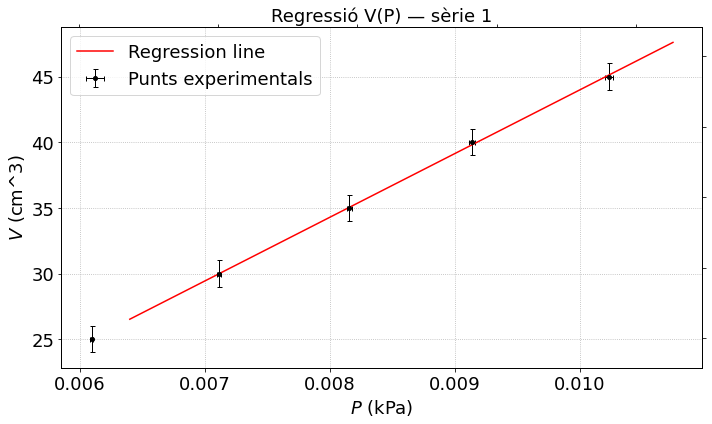

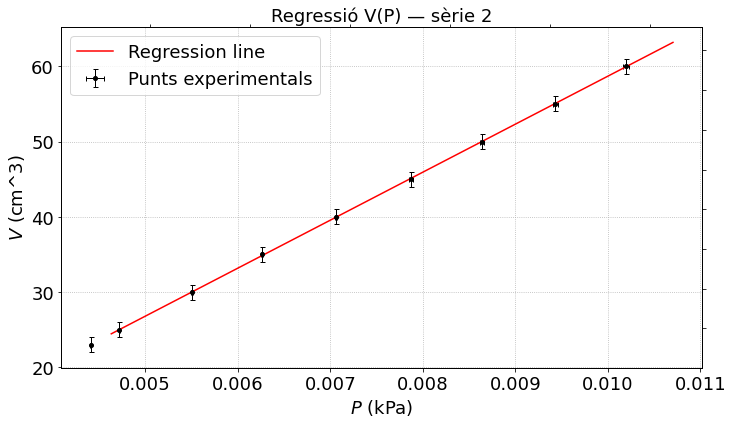

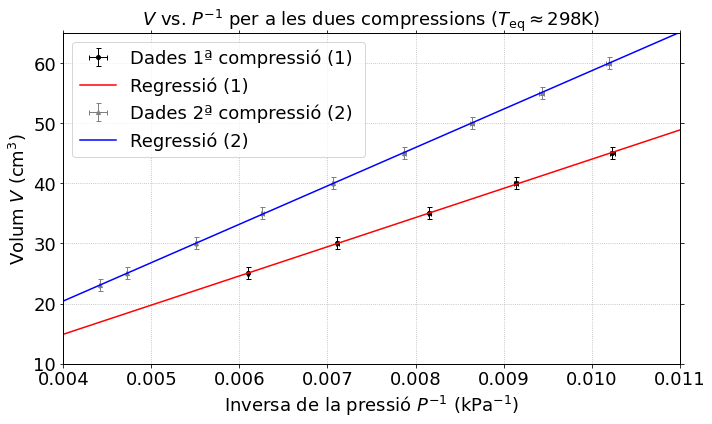

In [6]:


dV_cc = 1 # Check if this is fair for all cc measures
dP_kPa     = 0.3 # Més o menys estable...  

V_cc_vals  = [45, 40, 35, 30, 25] 
P_kPa_vals =[97.7, 109.4, 122.6, 140.6,164.1]
P_kPa_vals_inv = []

V_cc_vals_2  = [60,55,50,45, 40, 35, 30, 25,23]
P_kPa_vals_2 = [98.1,106.0, 115.7, 127.0, 141.6, 159.7, 181.6, 211.9,226.6] 
P_kPa_vals_inv_2 = []

# Build column Measures for each pair (V, P)
V_cols_cc, P_cols_kPa = [], []
for i, (Vcc, Pk) in enumerate(zip(V_cc_vals, P_kPa_vals)):
    V_meas = Measure(f"Volum cc {i}", f"Vcc_{i}", [Vcc, dV_cc], "cm^3")
    P_meas = Measure(f"Pressio kPa {i}", f"PkPa_{i}", [Pk, dP_kPa], "kPa")
    V_cols_cc.append(V_meas)
    P_cols_kPa.append(P_meas)
    P_kPa_vals_inv.append(inv_pressure(P_meas))

# — Build second dataset as Measures in original units (cm^3 and kPa) —
V_cols_cc_2, P_cols_kPa_2 = [], []
for i, (Vcc, Pk) in enumerate(zip(V_cc_vals_2, P_kPa_vals_2)):
    V_cols_cc_2.append(Measure(f"Volum cc (sèrie 2) {i}", f"Vcc2_{i}", [Vcc, dV_cc], "cm^3"))
    P_cols_kPa_2.append(Measure(f"Pressió kPa (sèrie 2) {i}", f"PkPa2_{i}", [Pk, dP_kPa], "kPa"))
    P_kPa_vals_inv_2.append(inv_pressure(Measure(f"Pressió kPa (sèrie 2) {i}", f"PkPa2_{i}", [Pk, dP_kPa], "kPa")))
# — Ensure first dataset volumes are in cm^3 for plotting (if they were 'cc', that equals cm^3) —


# — Datasets: (P, V_cc) —
dataset1 = list(zip(P_kPa_vals_inv,  V_cols_cc))
dataset2 = list(zip(P_kPa_vals_inv_2, V_cols_cc_2))

# — Linear regressions V ≈ a + b·P for each dataset —
a1, b1, r1, _, _ = regresio(
    dataset1, r"$P$", "kPa", r"$V$", r"cm^3",
    r"Regressió V(P) — sèrie 1", "display", fouraxis=True, grid=True
)
a2, b2, r2, _, _ = regresio(
    dataset2, r"$P$", "kPa", r"$V$", r"cm^3",
    r"Regressió V(P) — sèrie 2", "display", fouraxis=True, grid=True
)

# — Common x-range for both regressions (from overall min/max pressure) —
import numpy as np
P_inv_all = [p.magnitude for p in P_kPa_vals_inv] + [p.magnitude for p in P_kPa_vals_inv_2]
XMIN, XMAX = min(P_inv_all), max(P_inv_all)
P_inv_grid = np.linspace(0, 70, 400)

# — Regression lines spanning the whole graph domain —
reg1 = list(zip(P_inv_grid, a1.magnitude + b1.magnitude * P_inv_grid))
reg2 = list(zip(P_inv_grid, a2.magnitude + b2.magnitude * P_inv_grid))

# — Plot both datasets (points) + both regression lines (full span) —
graph_display(
    [dataset1, reg1, dataset2, reg2],
    r"Inversa de la pressió $P^{-1}$", "kPa$^{-1}$",
    r"Volum $V$", r"cm$^3$",
    r"$V$ vs. $P^{-1}$ per a les dues compressions ($T_{\mathrm{eq}} \approx 298 $K$)$",
    "V_vs_P_both",
    labels=[
        r"Dades 1ª compressió (1) ",
        r"Regressió (1)",
        r"Dades 2ª compressió (2)",
        r"Regressió (2)",
    ],
    llista_teos=["o", "-", "^", "-"],
    colors=["black", "red", "gray", "blue"],
    grid=True,
    fouraxis=True,xmin=0.004,xmax=0.011,ymax=65,ymin=10
)

print("Regressió sèrie 1: V = a + b·P^-1")
print("  a1 =", a1)
print("  b1 =", b1)
print("  r1 =", r1)
print("Regressió sèrie 2: V = a + b·P^-1")
print("  a2 =", a2)
print("  b2 =", b2)
print("  r2 =", r2)

n1 = moles_from_slope(b1,T_eq_K)
n2 = moles_from_slope(b2,T_eq_K_2)

print("Nombre de mols predits:\n")
print(n1)
print(n2)


Proportional regressió sèrie 1: V = a + b·P^-1
  a1 = 'A: (0.000000000000000 +/- 2.6198632059557507) cm^3'
  b1 = 'B: (4312.78228507163 +/- 316.51183727128125)  units '
  r1 = 'Coe: (0.9997871018568748 +/- 0.100000000000000)  '
Proportional egressió sèrie 2: V = a + b·P^-1
  a2 = 'A: (0.000000000000000 +/- 1.9289585245615006) cm^3'
  b2 = 'B: (5712.09515680508 +/- 261.22051971768497)  units '
  r2 = 'Coe: (0.9999571202273864 +/- 0.100000000000000)  '
Nombre de mols predits:

'Mols des de pendent: (0.00174074931949015 +/- 0.000127752632857755) mol'
'Mols des de pendent: (0.00229830620374454 +/- 0.000105106129072442) mol'


/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:165: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.
/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:166: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.


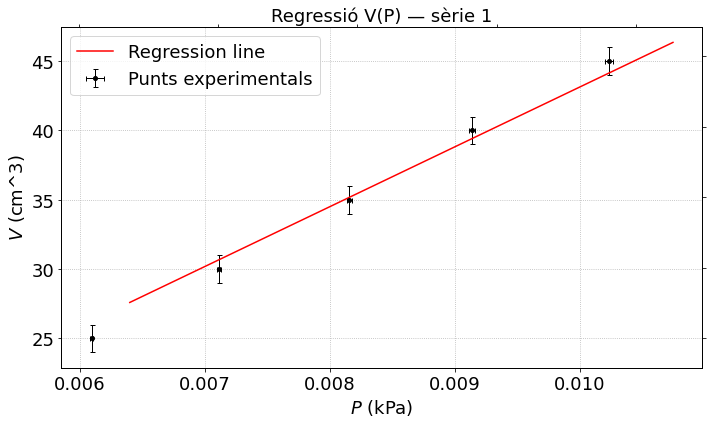

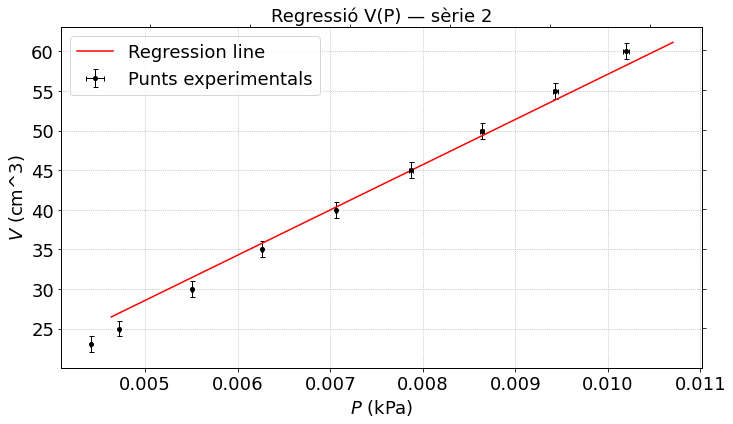

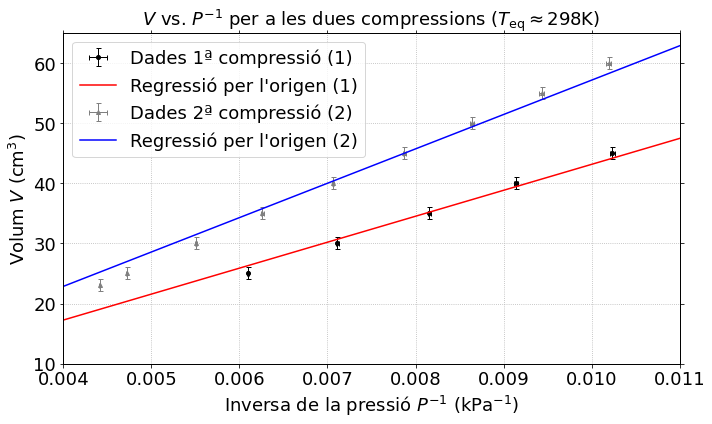

In [7]:
# — Linear regressions V ≈ a + b·P for each dataset —
a1p, b1p, r1p, _, _ = regresio(
    dataset1, r"$P$", "kPa", r"$V$", r"cm^3",
    r"Regressió V(P) — sèrie 1", "display", fouraxis=True, grid=True,proportional=True
)
a2p, b2p, r2p, _, _ = regresio(
    dataset2, r"$P$", "kPa", r"$V$", r"cm^3",
    r"Regressió V(P) — sèrie 2", "display", fouraxis=True, grid=True,proportional=True
)

# — Common x-range for both regressions (from overall min/max pressure) —
import numpy as np
P_inv_all = [p.magnitude for p in P_kPa_vals_inv] + [p.magnitude for p in P_kPa_vals_inv_2]
XMIN, XMAX = min(P_inv_all), max(P_inv_all)
P_inv_grid = np.linspace(0, 70, 400)

# — Regression lines spanning the whole graph domain —
reg1p = list(zip(P_inv_grid, a1p.magnitude + b1p.magnitude * P_inv_grid))
reg2p = list(zip(P_inv_grid, a2p.magnitude + b2p.magnitude * P_inv_grid))

# — Plot both datasets (points) + both regression lines (full span) —
graph_display(
    [dataset1, reg1p, dataset2, reg2p],
    r"Inversa de la pressió $P^{-1}$", "kPa$^{-1}$",
    r"Volum $V$", r"cm$^3$",
    r"$V$ vs. $P^{-1}$ per a les dues compressions ($T_{\mathrm{eq}} \approx 298 $K$)$",
    "V_vs_P_both",
    labels=[
        r"Dades 1ª compressió (1) ",
        r"Regressió per l'origen (1)",
        r"Dades 2ª compressió (2)",
        r"Regressió per l'origen (2)",
    ],
    llista_teos=["o", "-", "^", "-"],
    colors=["black", "red", "gray", "blue"],
    grid=True,
    fouraxis=True,xmin=0.004,xmax=0.011,ymax=65,ymin=10
)

print("Proportional regressió sèrie 1: V = a + b·P^-1")
print("  a1 =", a1p)
print("  b1 =", b1p)
print("  r1 =", r1p)
print("Proportional egressió sèrie 2: V = a + b·P^-1")
print("  a2 =", a2p)
print("  b2 =", b2p)
print("  r2 =", r2p)

print("Nombre de mols predits:\n")
n1p = moles_from_slope(b1p,T_eq_K)
n2p = moles_from_slope(b2p,T_eq_K_2)

print(n1p)
print(n2p)


In [8]:
tbl_1 = create_latex_table(
    [V_cols_cc, P_cols_kPa],                # columns: V, P
    [r"$V$", r"$P$"],        # column headers
    [r"cm^3", r"kPa"]                       # units (for your formatter)
)
print(tbl_1)

# --- Table: Sèrie 2 (compressió 2) ---
tbl_2 = create_latex_table(
    [V_cols_cc_2, P_cols_kPa_2],
    [r"$V$", r"$P$"],
    [r"cm^3", r"kPa"]
)
print(tbl_2)

\begin{tabular}{|cc|}
\hline
$V$ (cm^3)&$P$ (kPa)\\
\hline
$(4,50 \pm 0,1) \cdot 10$&$(97,70 \pm 0,3) $\\$(4,00 \pm 0,1) \cdot 10$&$(109,40 \pm 0,3) $\\$(3,50 \pm 0,1) \cdot 10$&$(122,60 \pm 0,3) $\\$(3,00 \pm 0,1) \cdot 10$&$(140,60 \pm 0,3) $\\$(2,50 \pm 0,1) \cdot 10$&$(164,10 \pm 0,3) $\\\hline
\end{tabular}
\begin{tabular}{|cc|}
\hline
$V$ (cm^3)&$P$ (kPa)\\
\hline
$(6,00 \pm 0,1) \cdot 10$&$(98,10 \pm 0,3) $\\$(5,50 \pm 0,1) \cdot 10$&$(106,00 \pm 0,3) $\\$(5,00 \pm 0,1) \cdot 10$&$(115,70 \pm 0,3) $\\$(4,50 \pm 0,1) \cdot 10$&$(127,00 \pm 0,3) $\\$(4,00 \pm 0,1) \cdot 10$&$(141,60 \pm 0,3) $\\$(3,50 \pm 0,1) \cdot 10$&$(159,70 \pm 0,3) $\\$(3,00 \pm 0,1) \cdot 10$&$(181,60 \pm 0,3) $\\$(2,50 \pm 0,1) \cdot 10$&$(211,90 \pm 0,3) $\\$(2,30 \pm 0,1) \cdot 10$&$(226,60 \pm 0,3) $\\\hline
\end{tabular}


In [11]:
def consecutive_pressure_volume_ratios(P_list, V_list, tag=""):
    """
    Build consecutive ratios for a series of Measures:
      • P2/P1 for i=0..n-2
      • V1/V2 for i=0..n-2
    Then aggregate each list with mean_or_measure_list.
    """
    n = min(len(P_list), len(V_list))
    if n < 2:
        return None, [], None, []

    P_ratios, V_ratios = [], []
    for i in range(n - 1):
        P21 = ratio_m(P_list[i+1], P_list[i], f"P2/P1 {tag} {i}->{i+1}", f"P21_{tag}_{i}", "")
        V12 = ratio_m(V_list[i],   V_list[i+1], f"V1/V2 {tag} {i}->{i+1}", f"V12_{tag}_{i}", "")
        P_ratios.append(P21)
        V_ratios.append(V12)

    P_ratios_agg = mean_or_measure_list(P_ratios, f"P2/P1 {tag} (agr.)", f"P21_{tag}_agg", "")
    V_ratios_agg = mean_or_measure_list(V_ratios, f"V1/V2 {tag} (agr.)", f"V12_{tag}_agg", "")
    return P_ratios_agg, P_ratios, V_ratios_agg, V_ratios

def ratio_m(num, den, name, varname, unit=""):
    """
    Return the Measure corresponding to num/den.
    Both num and den must be Measure (or compatible with .var).
    unit: resulting unit string (default dimensionless "").
    """
    # Basic guard against zero denominator magnitude (optional)
    if hasattr(den, "magnitude") and den.magnitude == 0:
        raise ZeroDivisionError(f"Denominator measure {den.name} has zero magnitude.")
    expr = num.var / den.var
    return formulador(expr, [num, den], name, varname, unit)

def mean_measure(vals, name, varname, unit):
    """
    Arithmetic mean of a list of Measures (no weighting).
    Returns a Measure via formulador, using .var to build the mean expression.
    """
    if not vals:
        return None
    n = float(len(vals))
    expr = sum(v.var for v in vals) / n
    return formulador(expr, vals, name, varname, unit)

P21_agg_1, P21_list_1, V12_agg_1, V12_list_1 = consecutive_pressure_volume_ratios(P_cols_kPa,  V_cols_cc,   tag="s1")
P21_agg_2, P21_list_2, V12_agg_2, V12_list_2 = consecutive_pressure_volume_ratios(P_cols_kPa_2, V_cols_cc_2, tag="s2")


/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:165: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.
/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:166: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.


In [21]:
def start_end_discrepancy(P_list, V_list, tag=""):
    """
    Use only the first and last points of a compression series.
    Returns (P21, V12, diff, prod_check, V21) as Measures and prints a short summary.
    """
    if len(P_list) < 2 or len(V_list) < 2:
        raise ValueError("Need at least two points (start and end) for both P and V.")

    P1, P2 = P_list[0], P_list[-1]
    V1, V2 = V_list[0], V_list[-1]

    # Ratios (dimensionless)
    P21 = ratio_m(P2, P1, f"P2/P1 {tag}", f"P21_{tag}", "")
    V12 = ratio_m(V1, V2, f"V1/V2 {tag}", f"V12_{tag}", "")
    V21 = ratio_m(V2, V1, f"V2/V1 {tag}", f"V21_{tag}", "")

    # Discrepancy and product check
    diff = formulador(P21.var - V12.var, [P21, V12], f"Δ={tag}: P2/P1 - V1/V2", f"Delta_{tag}", "")
    prod = formulador(P21.var * V21.var, [P21, V21], f"Check {tag}: (P2/P1)*(V2/V1)", f"Chk_{tag}", "")

    # Quick print
    try:
        rel_pct = 100.0 * (diff.magnitude / V12.magnitude)
    except Exception:
        rel_pct = None

    print(f"— {tag} —")
    print(" P2/P1 =", P21)
    print(" V1/V2 =", V12)
    print(" Δ = P2/P1 − V1/V2 =", diff, (f"(~{rel_pct:.2f}% of V1/V2)" if rel_pct is not None else ""))
    print(" Product check (should be ~1):", prod)

    return P21, V12, diff, prod, V21

# Run for your two compression series
P21_1, V12_1, diff_1, prod_1, V21_1 = start_end_discrepancy(P_cols_kPa,   V_cols_cc,   tag="s1")
P21_2, V12_2, diff_2, prod_2, V21_2 = start_end_discrepancy(P_cols_kPa_2, V_cols_cc_2, tag="s2")


— s1 —
 P2/P1 = 'P2/p1 s1: (1.67963152507677 +/- 0.00600239289697627) '
 V1/V2 = 'V1/v2 s1: (1.80000000000000 +/- 0.0823650411278960) '
 Δ = P2/P1 − V1/V2 = 'Δ=s1: p2/p1 - v1/v2: (-0.120368474923235 +/- 0.0825834651760852) ' (~-6.69% of V1/V2)
 Product check (should be ~1): 'Check s1: (p2/p1)*(v2/v1): (0.933128625042647 +/- 0.0428284493034033) '
— s2 —
 P2/P1 = 'P2/p1 s2: (2.30988786952090 +/- 0.00769742568052402) '
 V1/V2 = 'V1/v2 s2: (2.60869565217391 +/- 0.121469367307504) '
 Δ = P2/P1 − V1/V2 = 'Δ=s2: p2/p1 - v1/v2: (-0.298807782653016 +/- 0.121713013093064) ' (~-11.45% of V1/V2)
 Product check (should be ~1): 'Check s2: (p2/p1)*(v2/v1): (0.885457016649677 +/- 0.0413352134641231) '
V_corr (sèrie 1) = 'V_corr sèrie 1: (4.42771084337350 +/- 2.88795260786654) cm^3'
V_corr (sèrie 2) = 'V_corr sèrie 2: (5.24669260700390 +/- 1.92873879627262) cm^3'


/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:165: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.
/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:166: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.


In [22]:

def volume_correction(P1, P2, V1_exp, V2_exp, name="Correcció de volum (via r)", varname="V_corr_r", unit="cm^3"):
    # r = P2/P1  (dimensionless)
    r = ratio_m(P2, P1, "r = P2/P1", "r_P2P1", "")
    # Vc = (r*V2 - V1) / (1 - r)
    expr = (r.var * V2_exp.var - V1_exp.var) / (1.0 - r.var)
    return formulador(expr, [r, V2_exp, V1_exp], name, varname, unit)

# --- Evaluate V_c for each compression using first & last entries ---

# Sèrie 1
P1_1, P2_1 = P_cols_kPa[0],  P_cols_kPa[-1]
V1_1, V2_1 = V_cols_cc[0],    V_cols_cc[-1]
V_corr_1 = volume_correction(P1_1, P2_1, V1_1, V2_1, name="V_corr sèrie 1", varname="Vc_s1", unit="cm^3")
print("V_corr (sèrie 1) =", V_corr_1)

# Sèrie 2
P1_2, P2_2 = P_cols_kPa_2[0], P_cols_kPa_2[-1]
V1_2, V2_2 = V_cols_cc_2[0],  V_cols_cc_2[-1]
V_corr_2 = volume_correction(P1_2, P2_2, V1_2, V2_2, name="V_corr sèrie 2", varname="Vc_s2", unit="cm^3")
print("V_corr (sèrie 2) =", V_corr_2)



V_corr (sèrie 1) = 'V_corr sèrie 1: (4.42771084337350 +/- 2.88795260786654) cm^3'
V_corr (sèrie 2) = 'V_corr sèrie 2: (5.24669260700390 +/- 1.92873879627262) cm^3'


/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:165: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.
/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:166: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.


In [24]:
# Deltas between intercepts and volume corrections (all already computed)
delta_a1 = formulador(a1.var + V_corr_1.var, [a1, V_corr_1], "Δ a1−Vc1", "delta_a1_Vc1", "cm^3")
delta_a2 = formulador(a2.var + V_corr_2.var, [a2, V_corr_2], "Δ a2−Vc2", "delta_a2_Vc2", "cm^3")

# Pretty prints (relative to |Vc| for context)
rel1 = None if V_corr_1.magnitude == 0 else 100.0 * (delta_a1.magnitude / V_corr_1.magnitude)
rel2 = None if V_corr_2.magnitude == 0 else 100.0 * (delta_a2.magnitude / V_corr_2.magnitude)

print(" Δ = a1 − V_corr_1 =", delta_a1, (f"(~{rel1:.2f}% of V_corr_1)" if rel1 is not None else ""))
print(" Δ = a2 − V_corr_2 =", delta_a2, (f"(~{rel2:.2f}% of V_corr_2)" if rel2 is not None else ""))


 Δ = a1 − V_corr_1 = 'Δ a1−vc1: (-0.0720850539925246 +/- 2.90767360224969) cm^3' (~-1.63% of V_corr_1)
 Δ = a2 − V_corr_2 = 'Δ a2−vc2: (0.152474242895898 +/- 1.93225773180584) cm^3' (~2.91% of V_corr_2)


/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:165: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.
/opt/sagemath-9.3/local/lib/python3.7/site-packages/sage/repl/ipython_kernel/__main__.py:166: DeprecationWarning: Substitution using function-call syntax and unnamed arguments is deprecated and will be removed from a future release of Sage; you can use named arguments instead, like EXPR(x=..., y=...)
See http://trac.sagemath.org/5930 for details.
